### imports


In [1]:
import torch 
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


### check GPU

In [ ]:
if torch.cuda.is_available():
    gpu_count = torch.cuda.device_count()
    for i in range(gpu_count):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i + 1}: {gpu_name}")
else:
    print("GPU is not available!!!")


GPU 1: NVIDIA GeForce RTX 3060 Laptop GPU


### create dataset

In [ ]:
data_train = 'D:/ai/detect_plants/data/train'
data_validation = 'D:/ai/detect_plants/data/validation'
# Set the batch size and image size
batch_size = 32
img_height = 100  
img_width = 100   

train_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


validation_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


train_dataset = datasets.ImageFolder(root=data_train, transform=train_transforms)
validation_dataset = datasets.ImageFolder(root=data_validation, transform=validation_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

data_iter = iter(train_loader)
images, labels = next(data_iter) 

print(f"Batch of images shape: {images.shape}")
print(f"Batch of labels shape: {labels.shape}")


Batch of images shape: torch.Size([32, 3, 100, 100])
Batch of labels shape: torch.Size([32])


### show some data

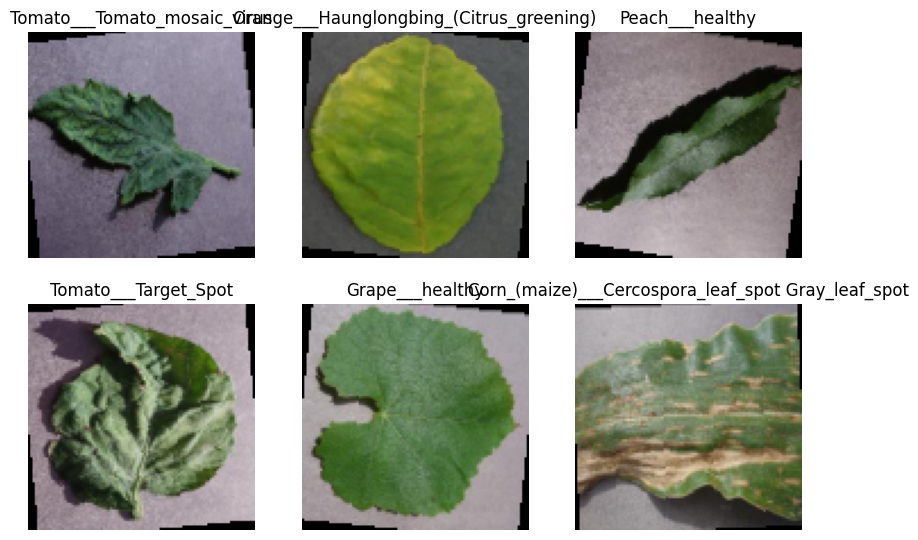

In [ ]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

images = images.permute(0, 2, 3, 1)

class_names = train_dataset.classes

plt.figure(figsize=(10, 10))

indices = np.arange(len(images))
np.random.shuffle(indices)
images = images[indices]
labels = labels[indices]

for i in range(6):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].numpy()

    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()



### create model

In [ ]:
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm2d(128)
        
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(128 * 12 * 12, 256)  # 128 * 12 * 12 برای تصاویر 100x100
        self.bn4 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.2)
        
        self.fc2 = nn.Linear(256, 128)
        self.bn5 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.2)
        
        self.fc3 = nn.Linear(128, 64)
        self.bn6 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.2)
        
        self.fc4 = nn.Linear(64, num_classes)
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        x = self.flatten(x)
        
        x = F.relu(self.bn4(self.fc1(x)))
        x = self.dropout1(x)
        
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.dropout2(x)
        
        x = F.relu(self.bn6(self.fc3(x)))
        x = self.dropout3(x)
        
        x = self.fc4(x)
        return x

num_classes = len(train_dataset.classes)

model = CNNModel(num_classes=num_classes)

print(model)



CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=18432, out_features=256, bias=True)
  (bn4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dr

### settings of model

In [ ]:
# Check if CUDA (GPU) is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Assuming model, train_loader, and validation_loader are already defined
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Using device: cuda


### fit model

In [7]:
from tqdm import tqdm
# Training loop
num_epochs = 50
train_loss_history = []
validation_loss_history = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    # Use tqdm to add a progress bar
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss = train_loss / len(train_loader.dataset)
    train_loss_history.append(train_loss)

    model.eval()
    validation_loss = 0.0
    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            validation_loss += loss.item() * images.size(0)

    validation_loss = validation_loss / len(validation_loader.dataset)
    validation_loss_history.append(validation_loss)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Validation Loss: {validation_loss:.4f}')

# Save the model
torch.save(model.state_dict(), './model/plants.pth')

Epoch 1/50: 100%|██████████| 2197/2197 [00:55<00:00, 39.63it/s]


Epoch 1/50, Train Loss: 1.1119, Validation Loss: 0.2975


Epoch 2/50: 100%|██████████| 2197/2197 [00:42<00:00, 52.18it/s]


Epoch 2/50, Train Loss: 0.4323, Validation Loss: 0.1832


Epoch 3/50: 100%|██████████| 2197/2197 [00:40<00:00, 53.60it/s]


...

Epoch 48/50, Train Loss: 0.0306, Validation Loss: 0.0213


Epoch 49/50: 100%|██████████| 2197/2197 [00:41<00:00, 53.15it/s]


Epoch 49/50, Train Loss: 0.0334, Validation Loss: 0.0190


Epoch 50/50: 100%|██████████| 2197/2197 [00:41<00:00, 52.95it/s]


Epoch 50/50, Train Loss: 0.0315, Validation Loss: 0.0193


### show model loss

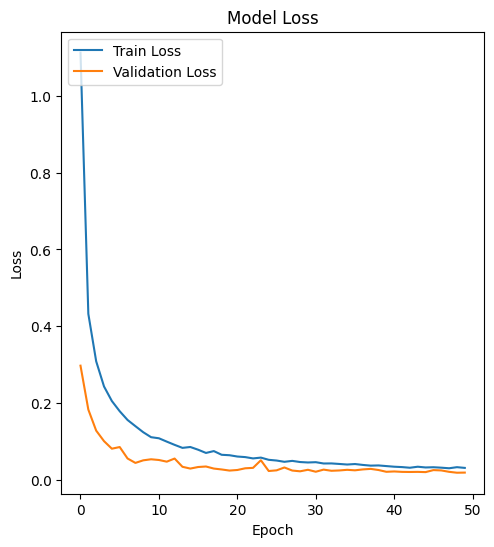

In [8]:
import matplotlib.pyplot as plt

# Assuming you have train_loss_history and validation_loss_history from the training loop

# Plot training & validation loss values
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(validation_loss_history, label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# If you also track accuracy, you can plot it similarly
# For example, if you have train_accuracy_history and validation_accuracy_history

# train_accuracy_history = []  # You need to track this during training
# validation_accuracy_history = []  # You need to track this during validation

# plt.subplot(1, 2, 2)
# plt.plot(train_accuracy_history, label='Train Accuracy')
# plt.plot(validation_accuracy_history, label='Validation Accuracy')
# plt.title('Model Accuracy')
# plt.ylabel('Accuracy')
# plt.xlabel('Epoch')
# plt.legend(loc='upper left')

plt.show()


### load model

In [9]:
model.load_state_dict(torch.load('./model/plants.pth'))

C:\Users\user\AppData\Local\Temp\ipykernel_18784\3160165705.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('./model/plants.pth'))


<All keys matched successfully>

### predict model

predictions:  tensor([[-19.7282, -14.6785, -14.2587, -13.0205, -14.6147, -15.6513, -10.5112,
         -21.6692, -33.6460, -18.8991, -27.1287, -11.6429, -11.1666, -14.0728,
         -13.6402, -21.0445, -17.9037, -19.1121, -18.9793,  -9.6139, -29.0837,
         -17.7058,  -9.0310,   7.3634, -10.9282, -22.2376, -14.1129, -11.2367,
         -16.3447, -14.9418, -14.9249, -12.0239, -18.5857,  -7.2519, -14.5942,
          -9.8075, -11.0614, -11.7379]], device='cuda:0')
---------------------------------
detected result: {'name': 'raspberry', 'healthy': True, 'problem': None}
---------------------------------


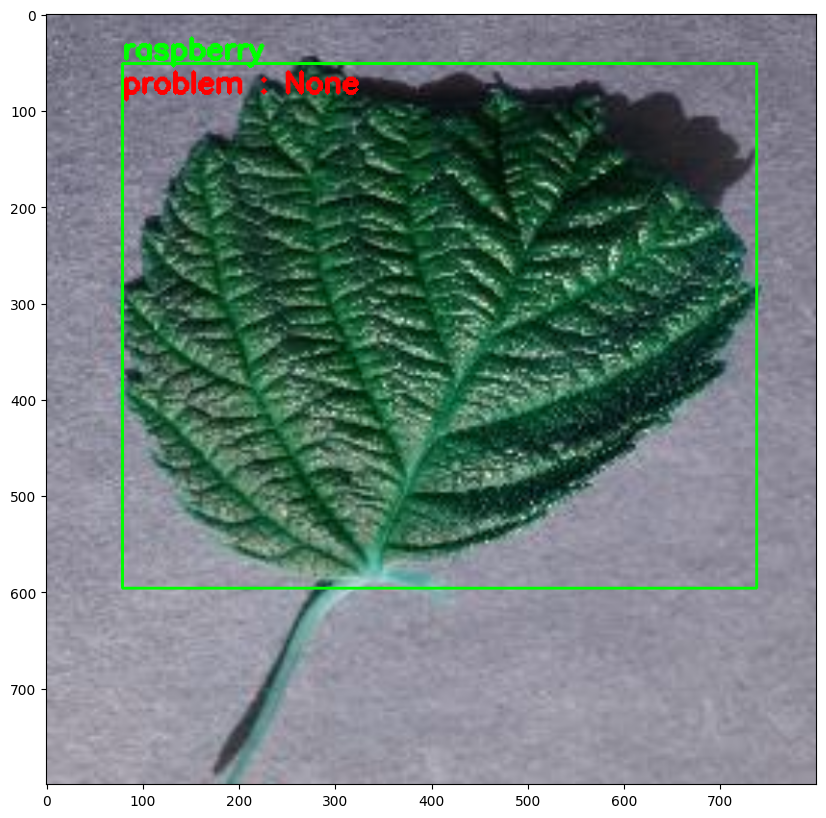

In [ ]:
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import cv2
import numpy as np

img_path = 'D:/ai/detect_plants/data/train/Raspberry___healthy/00a3fc0e-64cc-4e35-ac2f-aef04fda9b22___Mary_HL 9177.JPG'
img_open_cv = cv2.imread(img_path)
img_open_cv = cv2.resize(img_open_cv, (800, 800))
output = img_open_cv.copy()

preprocess = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

img = Image.open(img_path).convert("RGB")
img_tensor = preprocess(img)
img_tensor = img_tensor.unsqueeze(0)  

model.eval()

with torch.no_grad():
    img_tensor = img_tensor.to(device)
    predictions = model(img_tensor)
    predicted_class_idx = torch.argmax(predictions, dim=1).item()

hsv = cv2.cvtColor(img_open_cv, cv2.COLOR_BGR2HSV)
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])
mask = cv2.inRange(hsv, lower_green, upper_green)

contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

largest_contour = max(contours, key=cv2.contourArea)

list_plants = [
    {"name": "apple", "healthy": False, "problem": "apple_scab"},
    {"name": "apple", "healthy": False, "problem": "black_rot"},
    {"name": "apple", "healthy": False, "problem": "cedar_apple_rust"},
    {"name": "apple", "healthy": True, "problem": None},
    {"name": "blueberry", "healthy": True, "problem": None},
    {"name": "cherry (including sour)", "healthy": True, "problem": None},
    {"name": "cherry (including sour)", "healthy": False, "problem": "powdery_mildew"},
    {"name": "corn (maize)", "healthy": False, "problem": "cercospora_leaf_spot_gray_leaf_spot"},
    {"name": "corn (maize)", "healthy": False, "problem": "common_rust"},
    {"name": "corn (maize)", "healthy": True, "problem": None},
    {"name": "corn (maize)", "healthy": False, "problem": "northern_leaf_blight"},
    {"name": "grape", "healthy": False, "problem": "black_rot"},
    {"name": "grape", "healthy": False, "problem": "esca (black measles)"},
    {"name": "grape", "healthy": True, "problem": None},
    {"name": "grape", "healthy": False, "problem": "leaf_blight (isariopsis_leaf_spot)"},
    {"name": "orange", "healthy": False, "problem": "haunglongbing (citrus_greening)"},
    {"name": "peach", "healthy": False, "problem": "bacterial_spot"},
    {"name": "peach", "healthy": True, "problem": None},
    {"name": "pepper (bell)", "healthy": False, "problem": "bacterial_spot"},
    {"name": "pepper (bell)", "healthy": True, "problem": None},
    {"name": "potato", "healthy": False, "problem": "early_blight"},
    {"name": "potato", "healthy": True, "problem": None},
    {"name": "potato", "healthy": False, "problem": "late_blight"},
    {"name": "raspberry", "healthy": True, "problem": None},
    {"name": "soybean", "healthy": True, "problem": None},
    {"name": "squash", "healthy": False, "problem": "powdery_mildew"},
    {"name": "strawberry", "healthy": True, "problem": None},
    {"name": "strawberry", "healthy": False, "problem": "leaf_scorch"},
    {"name": "tomato", "healthy": False, "problem": "bacterial_spot"},
    {"name": "tomato", "healthy": False, "problem": "early_blight"},
    {"name": "tomato", "healthy": True, "problem": None},
    {"name": "tomato", "healthy": False, "problem": "late_blight"},
    {"name": "tomato", "healthy": False, "problem": "leaf_mold"},
    {"name": "tomato", "healthy": False, "problem": "septoria_leaf_spot"},
    {"name": "tomato", "healthy": False, "problem": "spider_mites (two-spotted_spider_mite)"},
    {"name": "tomato", "healthy": False, "problem": "target_spot"},
    {"name": "tomato", "healthy": False, "problem": "tomato_mosaic_virus"},
    {"name": "tomato", "healthy": False, "problem": "tomato_yellow_leaf_curl_virus"}
]

x, y, w, h = cv2.boundingRect(largest_contour)
cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)
cv2.putText(output, f'{list_plants[int(predicted_class_idx)]["name"]}', (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3)
cv2.putText(output, f'problem : {list_plants[int(predicted_class_idx)]["problem"]}', (x, y +30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 3)

print("predictions: ", predictions)
print("---------------------------------")
print("detected result:", list_plants[int(predicted_class_idx)])
print("---------------------------------")
plt.figure(figsize=[10,10])
plt.imshow(output)
plt.show()
